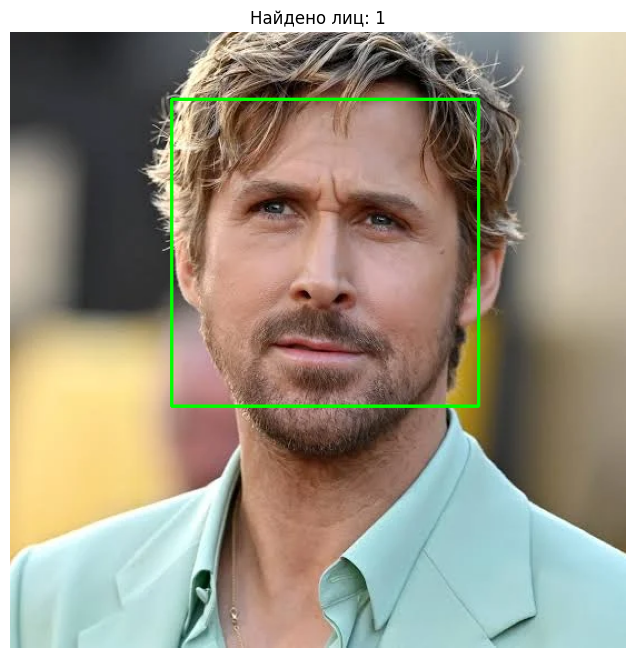

In [3]:
import cv2
import matplotlib.pyplot as plt
import time

image_path = r"C:\Users\Lenovo\OneDrive\Изображения\Saved Pictures\images.png"
image = cv2.imread(image_path)

if image is None:
    print("Ошибка: не удалось загрузить изображение")
else:
    
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    start = time.time()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))

    
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(image_rgb)
    plt.title(f"Найдено лиц: {len(faces)}")
    plt.axis('off')
    plt.show()

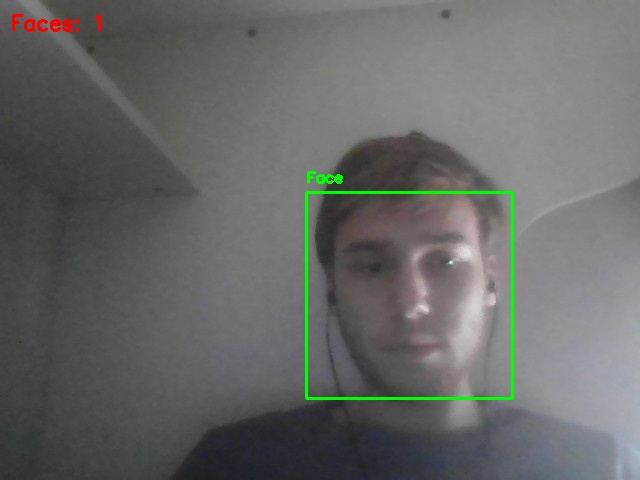

Остановлено пользователем
Камера освобождена


In [26]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output
import time

# Загружаем классификатор
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# й камеру
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Ошибка: не удалось открыть камеру.")
else:
    print("Нажмите кнопку Stop в Jupyter для остановки")
    
    try:
        while True:
            ret, frame = cap.read()
            
            if not ret:
                print("Ошибка при чтении видео.")
                break
            
            frame = cv2.resize(frame, (640, 480))
            
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
            
            for (x, y, w, h) in faces:
                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(frame, "Face", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            cv2.putText(frame, f"Faces: {len(faces)}", (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            ret, jpeg = cv2.imencode('.jpg', frame)
            if ret:
                clear_output(wait=True) 
                display(Image(data=jpeg.tobytes()))
            
            time.sleep(0.05)
            
    except KeyboardInterrupt:
        print("Остановлено пользователем")
    finally:
        cap.release()
        cv2.destroyAllWindows()
        print("Камера освобождена")

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from PIL import Image

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time


BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 43
IMG_SIZE = 32
DATA_DIR = './data'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [16]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.GTSRB(
    root=DATA_DIR,
    split='train',
    transform=transform,
    download=True
)

test_dataset = datasets.GTSRB(
    root=DATA_DIR,
    split='test',
    transform=transform,
    download=True
)

print(f"Тренировочных изображений: {len(train_dataset)}")
print(f"Тестовых изображений: {len(test_dataset)}")

100%|██████████| 187M/187M [00:22<00:00, 8.29MB/s] 
100%|██████████| 89.0M/89.0M [00:08<00:00, 10.6MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 865kB/s]


Тренировочных изображений: 26640
Тестовых изображений: 12630


In [17]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [19]:
class FullyConnectedNet(nn.Module):
    def __init__(self):
        super(FullyConnectedNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3 * IMG_SIZE * IMG_SIZE, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, NUM_CLASSES)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc4(x)
        return x

model = FullyConnectedNet().to(device)

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [23]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct / total
    scheduler.step(test_loss)
    
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')

Epoch 1/10 | Train Loss: 0.7748 | Train Acc: 76.54% | Test Loss: 0.9290 | Test Acc: 73.62%
Epoch 2/10 | Train Loss: 0.7552 | Train Acc: 77.45% | Test Loss: 0.8540 | Test Acc: 75.56%
Epoch 3/10 | Train Loss: 0.7160 | Train Acc: 78.54% | Test Loss: 0.8299 | Test Acc: 77.02%
Epoch 4/10 | Train Loss: 0.6893 | Train Acc: 79.24% | Test Loss: 0.8898 | Test Acc: 74.44%
Epoch 5/10 | Train Loss: 0.6737 | Train Acc: 79.87% | Test Loss: 0.9123 | Test Acc: 75.97%
Epoch 6/10 | Train Loss: 0.6466 | Train Acc: 80.71% | Test Loss: 0.7881 | Test Acc: 78.76%
Epoch 7/10 | Train Loss: 0.6259 | Train Acc: 81.21% | Test Loss: 0.7971 | Test Acc: 78.57%
Epoch 8/10 | Train Loss: 0.5942 | Train Acc: 82.32% | Test Loss: 0.8784 | Test Acc: 76.85%
Epoch 9/10 | Train Loss: 0.5670 | Train Acc: 83.07% | Test Loss: 0.7563 | Test Acc: 78.80%
Epoch 10/10 | Train Loss: 0.5548 | Train Acc: 83.25% | Test Loss: 0.8981 | Test Acc: 75.23%


In [24]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9667    0.4833    0.6444        60
           1     0.7938    0.8181    0.8057       720
           2     0.7734    0.6053    0.6791       750
           3     0.6633    0.5778    0.6176       450
           4     0.6205    0.2848    0.3904       660
           5     0.5671    0.5698    0.5685       630
           6     0.8800    0.7333    0.8000       150
           7     0.6422    0.7378    0.6867       450
           8     0.3258    0.9000    0.4784       450
           9     0.9674    0.8042    0.8783       480
          10     0.7262    0.9606    0.8271       660
          11     0.8588    0.8833    0.8709       420
          12     0.8932    0.9449    0.9183       690
          13     0.9726    0.9861    0.9793       720
          14     0.9231    0.8444    0.8820       270
          15     0.8395    0.6476    0.7312       210
          16     0.9466    0.8267    0.8826       150
   

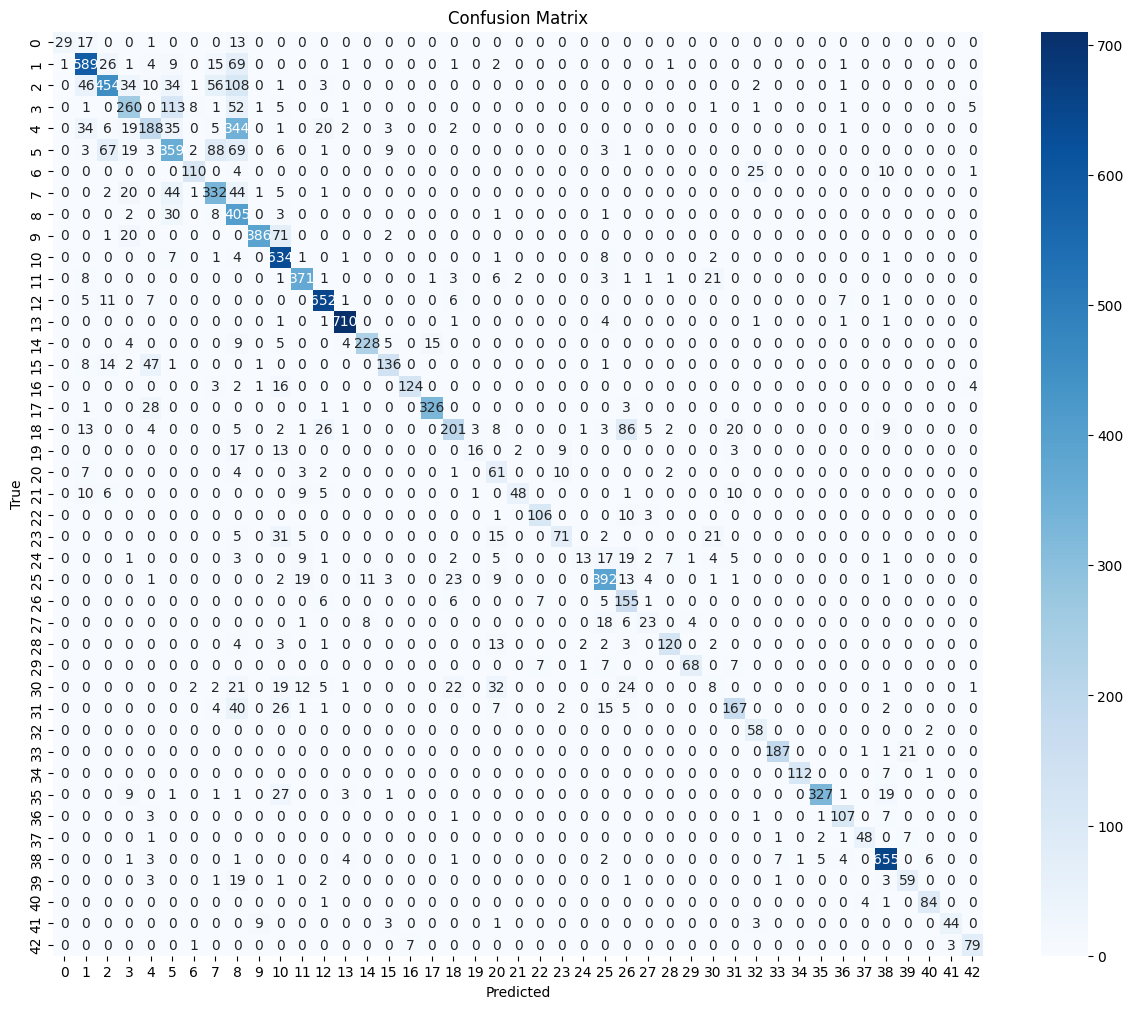

In [27]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## С помощью hog и метода опорных векторов

In [44]:
def get_hog_features(image):
    if isinstance(image, torch.Tensor):
        image = image.numpy().transpose(1, 2, 0)
    
    if len(image.shape) == 3:
        gray = cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        gray = (image * 255).astype(np.uint8)
    
    features = hog(gray, orientations=9, pixels_per_cell=(8, 8), 
                   cells_per_block=(2, 2), visualize=False, feature_vector=True)
    return features

In [45]:

X_train = []
y_train = []
X_test = []
y_test = []

print("Train:")
for idx in tqdm(range(len(train_dataset))):
    img, label = train_dataset[idx]
    X_train.append(get_hog_features(img))
    y_train.append(label)

print("Test:")
for idx in tqdm(range(len(test_dataset))):
    img, label = test_dataset[idx]
    X_test.append(get_hog_features(img))
    y_test.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train:


  0%|          | 0/26640 [00:00<?, ?it/s]

100%|██████████| 26640/26640 [00:19<00:00, 1400.31it/s]


Test:


100%|██████████| 12630/12630 [00:08<00:00, 1428.21it/s]


Train: (26640, 324), Test: (12630, 324)


In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [42]:

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)



,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [43]:
y_pred = svm.predict(X_test)
accuracy = np.mean(y_pred == y_test) * 100

print(f"\nAccuracy: {accuracy:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Accuracy: 68.00%

Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        60
           1     0.4763    0.6000    0.5310       720
           2     0.4525    0.5587    0.5000       750
           3     0.4834    0.5489    0.5140       450
           4     0.7869    0.7833    0.7851       660
           5     0.4734    0.4952    0.4841       630
           6     0.9706    0.6600    0.7857       150
           7     0.6746    0.6311    0.6521       450
           8     0.6938    0.6244    0.6573       450
           9     0.7465    0.7792    0.7625       480
          10     0.8970    0.9106    0.9038       660
          11     0.3168    0.5619    0.4052       420
          12     0.9353    0.9638    0.9493       690
          13     0.9916    0.9861    0.9889       720
          14     0.7695    0.7296    0.7490       270
          15     0.7853    0.7143    0.7481       210
          16     0.9362    0.8800    0.

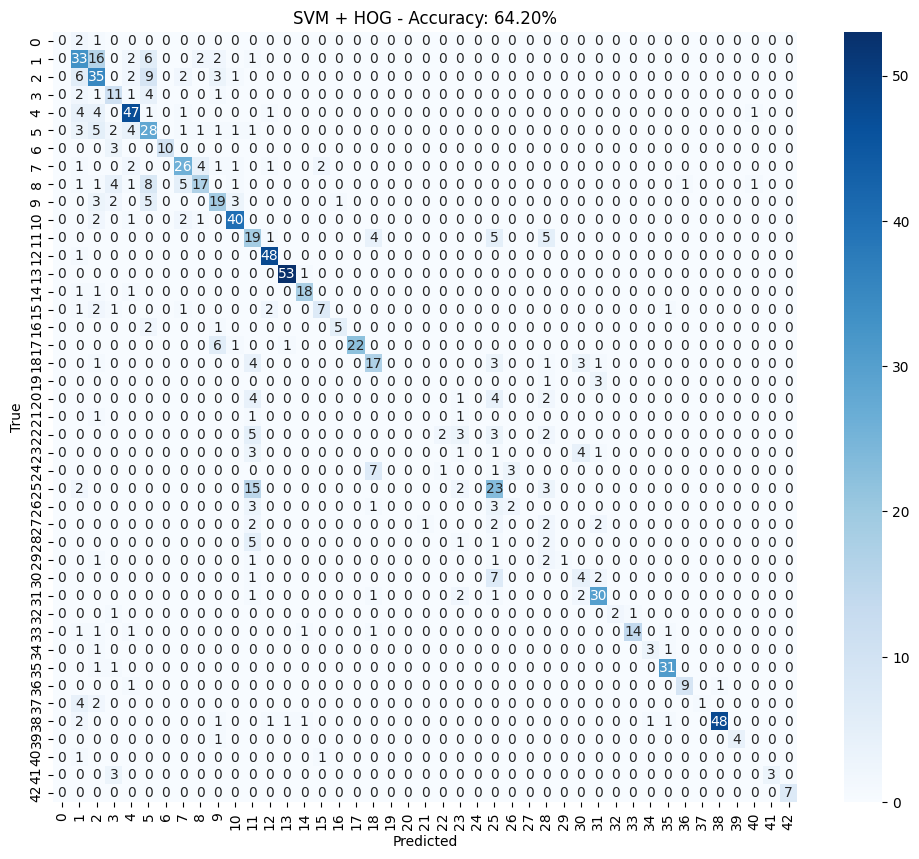

In [34]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'SVM + HOG - Accuracy: {accuracy:.2f}%')
plt.show()